In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('ecommerce_customer_churn_dataset.csv')
print("Shape:", df.shape)
print(df.head())


Shape: (50000, 25)
    Age  Gender Country        City  Membership_Years  Login_Frequency  \
0  43.0    Male  France   Marseille               2.9             14.0   
1  36.0    Male      UK  Manchester               1.6             15.0   
2  45.0  Female  Canada   Vancouver               2.9             10.0   
3  56.0  Female     USA    New York               2.6             10.0   
4  35.0    Male   India       Delhi               3.1             29.0   

   Session_Duration_Avg  Pages_Per_Session  Cart_Abandonment_Rate  \
0                  27.4                6.0                   50.6   
1                  42.7               10.3                   37.7   
2                  24.8                1.6                   70.9   
3                  38.4               14.8                   41.7   
4                  51.4                NaN                   19.1   

   Wishlist_Items  ...  Email_Open_Rate  Customer_Service_Calls  \
0             3.0  ...             17.9               

In [4]:
print("Duplicates before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [5]:
print("Missing values:\n", df.isnull().sum())

numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("\nAfter fix:\n", df.isnull().sum())

Missing values:
 Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

After fix:
 Age    

In [6]:
df['Gender'] = df['Gender'].str.strip().str.capitalize()
df['Country'] = df['Country'].str.strip().str.title()
df['City'] = df['City'].str.strip().str.title()

print(df['Gender'].unique())
print(df['Country'].unique())

['Male' 'Female' 'Other']
['France' 'Uk' 'Canada' 'Usa' 'India' 'Japan' 'Germany' 'Australia']


In [7]:
df['Age'] = df['Age'].astype(int)
df['Total_Purchases'] = df['Total_Purchases'].astype(int)
df['Churned'] = df['Churned'].astype(int)
print(df.dtypes)

Age                                int64
Gender                            object
Country                           object
City                              object
Membership_Years                 float64
Login_Frequency                  float64
Session_Duration_Avg             float64
Pages_Per_Session                float64
Cart_Abandonment_Rate            float64
Wishlist_Items                   float64
Total_Purchases                    int64
Average_Order_Value              float64
Days_Since_Last_Purchase         float64
Discount_Usage_Rate              float64
Returns_Rate                     float64
Email_Open_Rate                  float64
Customer_Service_Calls           float64
Product_Reviews_Written          float64
Social_Media_Engagement_Score    float64
Mobile_App_Usage                 float64
Payment_Method_Diversity         float64
Lifetime_Value                   float64
Credit_Balance                   float64
Churned                            int64
Signup_Quarter  

In [9]:
df.to_csv('churn_cleaned.csv', index=False)
print("✅ Clean data saved!")

✅ Clean data saved!


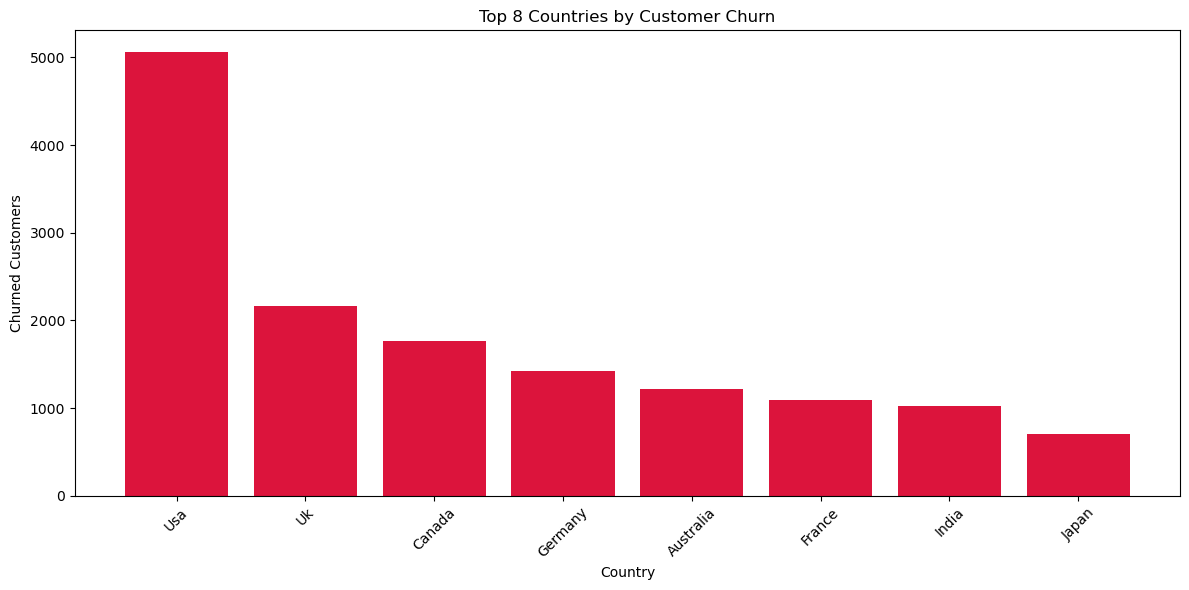

In [11]:
## Bar chart
plt.figure(figsize=(12,6))
churn_country = df[df['Churned']==1]['Country'].value_counts().head(8)
plt.bar(churn_country.index, churn_country.values, color='crimson')
plt.title('Top 8 Countries by Customer Churn')
plt.xlabel('Country')
plt.ylabel('Churned Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('bar_chart.png')
plt.show()

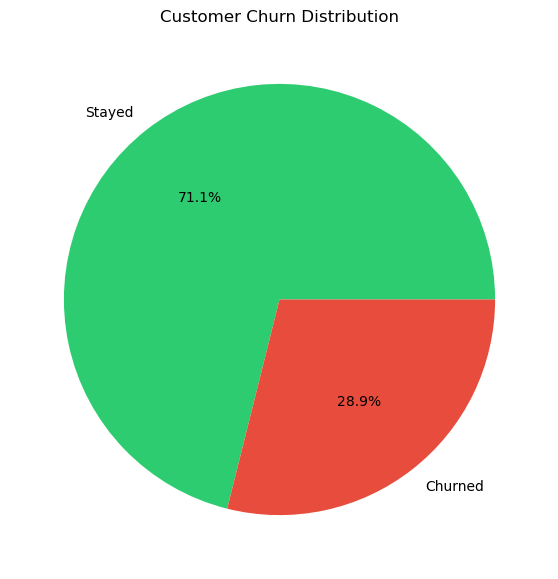

In [12]:
## Pie Chart:
plt.figure(figsize=(7,7))
sizes = df['Churned'].value_counts()
labels = ['Stayed', 'Churned']
colors = ['#2ecc71', '#e74c3c']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Customer Churn Distribution')
plt.savefig('pie_chart.png')
plt.show()

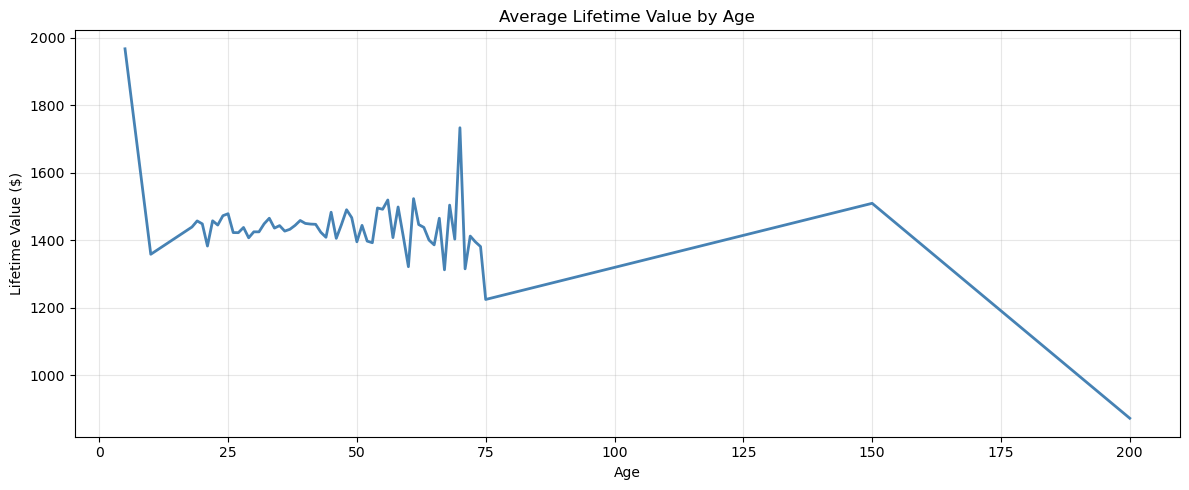

In [13]:
## Line Chart:
plt.figure(figsize=(12,5))
age_ltv = df.groupby('Age')['Lifetime_Value'].mean()
plt.plot(age_ltv.index, age_ltv.values, color='steelblue', linewidth=2)
plt.title('Average Lifetime Value by Age')
plt.xlabel('Age')
plt.ylabel('Lifetime Value ($)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('line_chart.png')
plt.show()

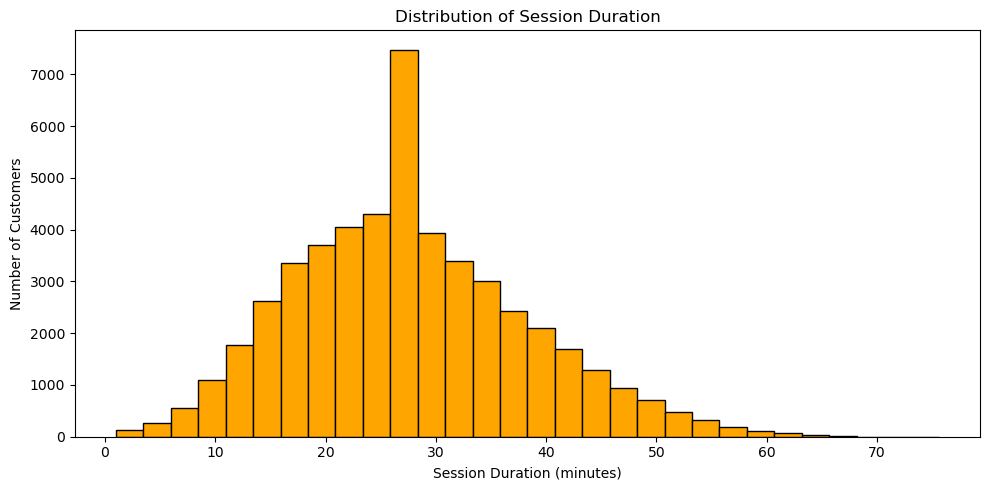

In [14]:
## Histogram:
plt.figure(figsize=(10,5))
plt.hist(df['Session_Duration_Avg'], bins=30,
         color='orange', edgecolor='black')
plt.title('Distribution of Session Duration')
plt.xlabel('Session Duration (minutes)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('histogram.png')
plt.show()

In [16]:
# ==========================================
# MapReduce Simulation - Churn Count by Country
# ==========================================

import pandas as pd
from collections import defaultdict

df = pd.read_csv('churn_cleaned.csv')

# ========== MAP PHASE ==========
# كل صف بيطلع (Country, 1) لو العميل Churned
def mapper(dataframe):
    mapped = []
    for _, row in dataframe.iterrows():
        if row['Churned'] == 1:
            mapped.append((row['Country'], 1))
    return mapped

# ========== SHUFFLE PHASE ==========
# تجميع نفس الـ Country مع بعض
def shuffle(mapped_data):
    shuffled = defaultdict(list)
    for country, value in mapped_data:
        shuffled[country].append(value)
    return shuffled

# ========== REDUCE PHASE ==========
# جمع العدد لكل Country
def reducer(shuffled_data):
    result = {}
    for country, values in shuffled_data.items():
        result[country] = sum(values)
    return result

# ========== RUN MAPREDUCE ==========
print("🔵 MAP Phase running...")
mapped = mapper(df)
print(f"   Mapped {len(mapped)} churned customers")

print("\n🟡 SHUFFLE Phase running...")
shuffled = shuffle(mapped)
print(f"   Grouped into {len(shuffled)} countries")

print("\n🔴 REDUCE Phase running...")
result = reducer(shuffled)

# ========== SHOW RESULTS ==========
result_df = pd.DataFrame(list(result.items()),
                         columns=['Country', 'Churned_Count'])
result_df = result_df.sort_values('Churned_Count', ascending=False)

print("\n✅ MapReduce Result:")
print(result_df.to_string(index=False))

🔵 MAP Phase running...
   Mapped 14450 churned customers

🟡 SHUFFLE Phase running...
   Grouped into 8 countries

🔴 REDUCE Phase running...

✅ MapReduce Result:
  Country  Churned_Count
      Usa           5056
       Uk           2169
   Canada           1768
  Germany           1420
Australia           1214
   France           1095
    India           1019
    Japan            709


---
## Machine Learning Models for Churn Prediction

Using the cleaned data to train and evaluate 3 ML models:
- **Logistic Regression**
- **Random Forest**
- **Gradient Boosting**

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Reload clean data
df_ml = pd.read_csv('churn_cleaned.csv')

# --- Encode categoricals ---
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
print('Categorical columns to encode:', cat_cols)
for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

# --- Split ---
target_col = 'Churned'
X = df_ml.drop(columns=[target_col])
y = df_ml[target_col]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# --- Scale (for Logistic Regression) ---
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Churn distribution:\n{y.value_counts()}')

Categorical columns to encode: ['Gender', 'Country', 'City', 'Signup_Quarter']
Train: (40000, 24) | Test: (10000, 24)
Churn distribution:
Churned
0    35550
1    14450
Name: count, dtype: int64


### Model 1 — Logistic Regression

In [19]:
lr = LogisticRegression(max_iter=500, random_state=42)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
y_prob_lr  = lr.predict_proba(X_test_sc)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}')
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy : 0.7753
ROC-AUC  : 0.7909
              precision    recall  f1-score   support

           0       0.80      0.92      0.85      7110
           1       0.68      0.42      0.52      2890

    accuracy                           0.78     10000
   macro avg       0.74      0.67      0.69     10000
weighted avg       0.76      0.78      0.76     10000



### Model 2 — Random Forest

In [20]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy : 0.9167
ROC-AUC  : 0.9260
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7110
           1       0.92      0.78      0.84      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.89     10000
weighted avg       0.92      0.92      0.91     10000



### Model 3 — Gradient Boosting

In [21]:
gb = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb  = gb.predict_proba(X_test)[:, 1]

print('=== Gradient Boosting ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_gb):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob_gb):.4f}')
print(classification_report(y_test, y_pred_gb))

=== Gradient Boosting ===
Accuracy : 0.9194
ROC-AUC  : 0.9277
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      7110
           1       0.94      0.77      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.93      0.88      0.90     10000
weighted avg       0.92      0.92      0.92     10000



### Model Comparison

FileNotFoundError: [Errno 2] No such file or directory: '/work/work/model_comparison.png'

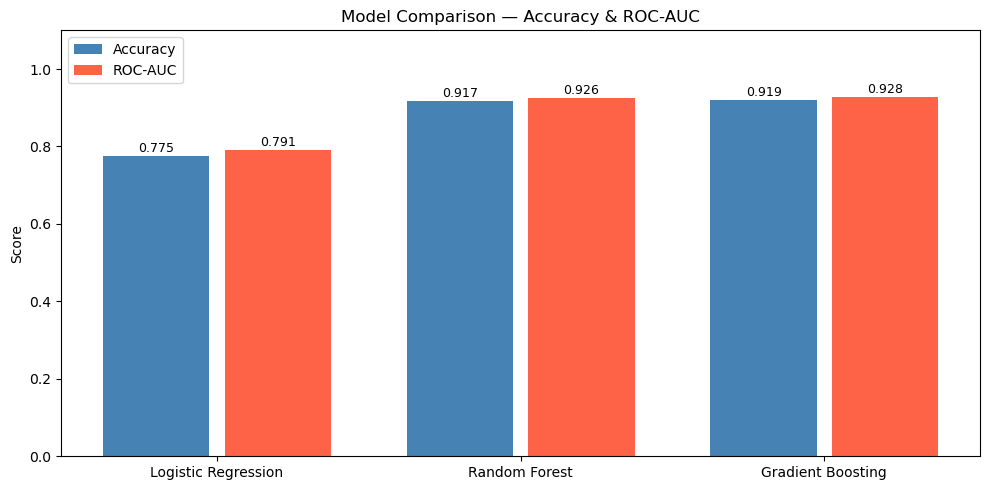

In [22]:
models  = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
acc     = [accuracy_score(y_test, y_pred_lr),
           accuracy_score(y_test, y_pred_rf),
           accuracy_score(y_test, y_pred_gb)]
auc     = [roc_auc_score(y_test, y_prob_lr),
           roc_auc_score(y_test, y_prob_rf),
           roc_auc_score(y_test, y_prob_gb)]

x = np.arange(len(models))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 0.2, acc, 0.35, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + 0.2, auc, 0.35, label='ROC-AUC',  color='tomato')
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, 1.1); ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & ROC-AUC')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150); plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, prob in [('Logistic Regression', y_prob_lr),
                   ('Random Forest',       y_prob_rf),
                   ('Gradient Boosting',   y_prob_gb)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, prob):.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('work/roc_curves.png', dpi=150); plt.show()

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name, preds in zip(axes,
                            ['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
                            [y_pred_lr, y_pred_rf, y_pred_gb]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
    ax.set_title(name); ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout(); plt.savefig('work/confusion_matrices.png', dpi=150); plt.show()

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 5))
feat_imp.head(10).plot(kind='bar', color='darkorange', edgecolor='black')
plt.title('Top 10 Feature Importances — Random Forest')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.savefig('work/feature_importance.png', dpi=150); plt.show()

### Summary Table

In [ ]:
summary = pd.DataFrame({
    'Model'   : models,
    'Accuracy': [f'{v:.4f}' for v in acc],
    'ROC-AUC' : [f'{v:.4f}' for v in auc],
})
print(summary.to_string(index=False))